# 第二次作业：sklearn-KNN 算法源码解析

> 主题：阅读 scikit-learn 的实现，分享那些特别的数学与工程实现。

环境：`sklearn 1.3.2` / Python 3.8，文中行号均以 1.3.2 版本的库为准。

## 1. KNN

KNN（k-Nearest Neighbors，k 近邻）是一种**非参数、基于实例的学习**：它没有显式的训练过程，只是把训练集原样"记下来"；预测时在训练集中找出与待预测样本**距离最近的 k 个样本**，再依据它们的目标值做决策。

**算法流程**：

1. 计算待预测样本到所有训练样本的距离；
2. 选出距离最小的 k 个样本（k 是超参数）；
3. 对这 k 个近邻的类别做**多数投票**，得票最多的类别即为预测结果；
4. 回归任务把第 3 步换成「取目标均值」即可。

它的决策完全由**局部邻域**决定，因此对 k 与距离度量都很敏感：k 太小容易被噪声点带偏，k 太大又会抹平局部结构。

**算法规则**：找 k 个近邻 → 多数投票；`weights='distance'` 时按距离倒数加权；回归取近邻目标均值或加权均值。

| 类别 | 本作业主要关注点 |
|---|---|
| **A. 数学层面** | 全程用**平方**距离、最后才开方；`minkowski` 会**坍缩**成 manhattan/euclidean/chebyshev；`0<p<1` 是**半度量**导致树算法被禁用；`weights='distance'` 的**零距离特判**；半径结果用**稳定排序** |
| **B. 数据结构层面** | Top-k 用 `np.argpartition`（O(n)）**而非全排序**；`algorithm='auto'` 的**硬编码启发式**；稀疏距离矩阵当图输入（KNN「可以没有坐标」）；半径版返回**变长 object 数组** |
| **C. 架构工程层面** | `fit` 不训练、**索引可跨模型复用**；`NeighborsBase` 是 ABC 且 `__init__` 被标 `@abstractmethod`；`kneighbors` 有**四条执行路径**；同一个 `n_jobs` 在树 / 暴力后端语义不同；`query==train` 的自身排除与**重复点边界** |

## 2. 定位源码：neighbors 包的可分析边界

KNN 的实现集中在 `sklearn/neighbors/`。

**哪些文件能看到源码**——scikit-learn 把性能敏感的部分用 Cython 写了，这些部分难以分析，我们主要关注 Python 部分。

In [1]:
import sklearn, os, sys
import numpy as np

sk_dir = os.path.dirname(sklearn.__file__)
nb_dir = os.path.join(sk_dir, "neighbors")

print("python       :", sys.version.split()[0])
print("sklearn      :", sklearn.__version__)
print("sklearn path :", sk_dir)
print("neighbors    :", nb_dir)
print()

pure, compiled = [], []
for f in sorted(os.listdir(nb_dir)):
    if f.endswith(".py"):
        pure.append(f)
    elif f.endswith(".so"):
        compiled.append(f)

print("== 纯 Python（可 inspect.getsource 逐行读）==")
for f in pure:
    print("   ", f)

print()
print("== 编译产物 .so（只有二进制，没有源码可读）==")
for f in compiled:
    print("   ", f)

python       : 3.8.20
sklearn      : 1.3.2
sklearn path : /root/MSA/ENTER/envs/vmunet/lib/python3.8/site-packages/sklearn
neighbors    : /root/MSA/ENTER/envs/vmunet/lib/python3.8/site-packages/sklearn/neighbors

== 纯 Python（可 inspect.getsource 逐行读）==
    __init__.py
    _base.py
    _classification.py
    _graph.py
    _kde.py
    _lof.py
    _nca.py
    _nearest_centroid.py
    _regression.py
    _unsupervised.py

== 编译产物 .so（只有二进制，没有源码可读）==
    _ball_tree.cpython-38-x86_64-linux-gnu.so
    _kd_tree.cpython-38-x86_64-linux-gnu.so
    _partition_nodes.cpython-38-x86_64-linux-gnu.so
    _quad_tree.cpython-38-x86_64-linux-gnu.so


## 3. 索引复用

`fit` 不"训练参数"，只校验数据、为查询建立**空间索引**（KDTree / BallTree）。所以：

- `self._fit_X`（训练集本身）就是"模型"；模型大小 = O(n·d)，预测代价随训练集增长。

注：如果传给 `fit` 的 `X` **本身已经是一个建好索引的对象**（`NeighborsBase` / `KDTree` / `BallTree`），sklearn 会**直接复用它的索引，完全不再重建**。这让"预建索引 + 多个模型共享同一棵树"成为可能。

In [2]:
import inspect
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.neighbors._base import NeighborsBase

lines = inspect.getsource(NeighborsBase._fit).splitlines()
i = next(k for k, l in enumerate(lines) if "isinstance(X, NeighborsBase)" in l)

print("# NeighborsBase._fit() —— X 已是「建好索引的对象」时直接复用 (L527-L546)")
print("\n".join(lines[i:i + 22]))

# NeighborsBase._fit() —— X 已是「建好索引的对象」时直接复用 (L527-L546)
        if isinstance(X, NeighborsBase):
            self._fit_X = X._fit_X
            self._tree = X._tree
            self._fit_method = X._fit_method
            self.n_samples_fit_ = X.n_samples_fit_
            return self

        elif isinstance(X, BallTree):
            self._fit_X = X.data
            self._tree = X
            self._fit_method = "ball_tree"
            self.n_samples_fit_ = X.data.shape[0]
            return self

        elif isinstance(X, KDTree):
            self._fit_X = X.data
            self._tree = X
            self._fit_method = "kd_tree"
            self.n_samples_fit_ = X.data.shape[0]
            return self

        if self.metric == "precomputed":


In [3]:
rng = np.random.RandomState(0)
X_idx = rng.rand(20, 2)
y_idx = np.array([0] * 10 + [1] * 10)

# 先单独建一个带索引的「无监督近邻」对象
base = NearestNeighbors(n_neighbors=3, algorithm="kd_tree").fit(X_idx)
print("base._fit_method =", base._fit_method)
print("base._tree       =", type(base._tree).__name__)

# 关键：把这个「已建好索引的对象」当作 X 传给分类器
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(base, y_idx)

print()
print("clf._fit_method        =", clf._fit_method)
print("clf._tree is base._tree =", clf._tree is base._tree, "  <- True 表示树被复用，没有重建")
print("n_samples_fit_         =", clf.n_samples_fit_)
print("预测前 5 个样本         =", clf.predict(X_idx[:5]))

base._fit_method = kd_tree
base._tree       = KDTree

clf._fit_method        = kd_tree
clf._tree is base._tree = True   <- True 表示树被复用，没有重建
n_samples_fit_         = 20
预测前 5 个样本         = [1 1 1 0 0]


## 4. 抽象基类与 Mixin 组合

sklearn 把KNN拆成了**一个抽象基类 + 两个查询 Mixin**：

- `NeighborsBase`：只放**参数、校验、建索引**（`fit`），**不含任何查询逻辑**；它用 `ABCMeta` 声明为抽象基类，甚至把 `__init__` 标成 `@abstractmethod`——强制每个子类自定义构造器。
- `KNeighborsMixin`：固定 k 的查询（`kneighbors`）；
- `RadiusNeighborsMixin`：固定半径的查询（`radius_neighbors`）。

组合的好处：`NearestNeighbors`、`KNeighborsClassifier/Regressor`、`LocalOutlierFactor`、`KNeighborsTransformer` **共用同一套查询内核**，各自只重写"聚合方式"。

参数校验不是手写 `if`，而是声明式的 `_parameter_constraints` 字典。

In [4]:
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.neighbors._base import NeighborsBase

print("KNeighborsClassifier 的 MRO（方法解析顺序）：")
for c in KNeighborsClassifier.__mro__:
    print("    ", c.__name__)

print()
print("NeighborsBase 的抽象方法 =", NeighborsBase.__abstractmethods__,
      " <- 连 __init__ 都被抽象了，在子类里实现")

mixins = [c.__name__ for c in NearestNeighbors.__mro__
          if c.__name__ in ("KNeighborsMixin", "RadiusNeighborsMixin")]
print()
print("NearestNeighbors 同时继承两个查询 Mixin :", mixins)

print()
print("声明式参数校验 _parameter_constraints：")
for k, v in KNeighborsClassifier._parameter_constraints.items():
    print("    ", k, "->", v)

KNeighborsClassifier 的 MRO（方法解析顺序）：
     KNeighborsClassifier
     KNeighborsMixin
     ClassifierMixin
     NeighborsBase
     MultiOutputMixin
     BaseEstimator
     _MetadataRequester
     object

NeighborsBase 的抽象方法 = frozenset({'__init__'})  <- 连 __init__ 都被抽象了，在子类里实现

NearestNeighbors 同时继承两个查询 Mixin : ['KNeighborsMixin', 'RadiusNeighborsMixin']

声明式参数校验 _parameter_constraints：
     n_neighbors -> [<sklearn.utils._param_validation.Interval object at 0x7fbd663591c0>, None]
     algorithm -> [<sklearn.utils._param_validation.StrOptions object at 0x7fbd6635f280>]
     leaf_size -> [<sklearn.utils._param_validation.Interval object at 0x7fbd6635f310>]
     p -> [<sklearn.utils._param_validation.Interval object at 0x7fbd6635f340>, None]
     metric -> [<sklearn.utils._param_validation.StrOptions object at 0x7fbd6635f400>, <built-in function callable>]
     metric_params -> [<class 'dict'>, None]
     n_jobs -> [<class 'numbers.Integral'>, None]
     weights -> [<sklearn.utils._param_va

## 5. `algorithm="auto"` 的硬编码启发式

理论上"数据多就用树、维度高就用暴力"，但**具体阈值**是 sklearn 写死在源码里的经验规则。`algorithm="auto"` 时（`_fit`，L586–619）：

- `metric="precomputed"` → `brute`
- `n_features > 15` → `brute`
- `n_neighbors >= n_samples // 2` → `brute`（近邻数接近样本数时树没优势）
- 带权重 `w` 的 minkowski → `ball_tree`（KDTree 不支持加权 minkowski）
- 否则看 metric 是否在 `KDTree.valid_metrics` 里，是就 `kd_tree`，否则退 `ball_tree`，再退 `brute`

其中 **KDTree 支持的 metric 是 BallTree 的子集**——因为 KDTree 只能按单个维度切分，metric 必须能逐维分解。

In [5]:
import inspect
from sklearn.neighbors._base import NeighborsBase

lines = inspect.getsource(NeighborsBase._fit).splitlines()
s = next(k for k, l in enumerate(lines) if 'if self._fit_method == "auto":' in l)
e = next(k for k, l in enumerate(lines) if 'if self._fit_method == "ball_tree":' in l)

print("# NeighborsBase._fit() —— algorithm='auto' 的硬编码启发式 (L586-L619)")
print("\n".join(lines[s:e]))

# NeighborsBase._fit() —— algorithm='auto' 的硬编码启发式 (L586-L619)
        if self._fit_method == "auto":
            # A tree approach is better for small number of neighbors or small
            # number of features, with KDTree generally faster when available
            if (
                self.metric == "precomputed"
                or self._fit_X.shape[1] > 15
                or (
                    self.n_neighbors is not None
                    and self.n_neighbors >= self._fit_X.shape[0] // 2
                )
            ):
                self._fit_method = "brute"
            else:
                if (
                    self.effective_metric_ == "minkowski"
                    and self.effective_metric_params_["p"] < 1
                ):
                    self._fit_method = "brute"
                elif (
                    self.effective_metric_ == "minkowski"
                    and self.effective_metric_params_.get("w") is not None
                ):
                 

In [6]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors._base import VALID_METRICS

print("KDTree  支持的 metric :", VALID_METRICS["kd_tree"])
print()
print("BallTree 支持的 metric:", VALID_METRICS["ball_tree"])
print()
print("BallTree 比 KDTree 多出:",
      sorted(set(VALID_METRICS["ball_tree"]) - set(VALID_METRICS["kd_tree"])))

KDTree  支持的 metric : ['euclidean', 'l2', 'minkowski', 'p', 'manhattan', 'cityblock', 'l1', 'chebyshev', 'infinity']

BallTree 支持的 metric: ['euclidean', 'l2', 'minkowski', 'p', 'manhattan', 'cityblock', 'l1', 'chebyshev', 'infinity', 'seuclidean', 'mahalanobis', 'hamming', 'canberra', 'braycurtis', 'jaccard', 'dice', 'rogerstanimoto', 'russellrao', 'sokalmichener', 'sokalsneath', 'haversine', 'pyfunc']

BallTree 比 KDTree 多出: ['braycurtis', 'canberra', 'dice', 'hamming', 'haversine', 'jaccard', 'mahalanobis', 'pyfunc', 'rogerstanimoto', 'russellrao', 'seuclidean', 'sokalmichener', 'sokalsneath']


In [7]:
rng = np.random.RandomState(0)
y = rng.randint(0, 2, 40)

def auto_fit_method(n_features, n_neighbors):
    X = rng.rand(40, n_features)
    return KNeighborsClassifier(n_neighbors=n_neighbors, algorithm="auto").fit(X, y)._fit_method

print("随「特征维度」变化（n_samples=40, k=3）：")
for d in (2, 10, 15, 16, 30):
    print(f"    n_features={d:>2}  ->  {auto_fit_method(d, 3)}")

print()
print("随「n_neighbors」变化（n_features=2, n_samples=40，阈值是 40//2=20）：")
for k in (3, 19, 20, 25):
    print(f"    n_neighbors={k:>2}  ->  {auto_fit_method(2, k)}")

随「特征维度」变化（n_samples=40, k=3）：
    n_features= 2  ->  kd_tree
    n_features=10  ->  kd_tree
    n_features=15  ->  kd_tree
    n_features=16  ->  brute
    n_features=30  ->  brute

随「n_neighbors」变化（n_features=2, n_samples=40，阈值是 40//2=20）：
    n_neighbors= 3  ->  kd_tree
    n_neighbors=19  ->  kd_tree
    n_neighbors=20  ->  brute
    n_neighbors=25  ->  brute


## 6. 距离的等价变换与度量特化

**1｜平方欧氏 + 延迟开方。** 找"最近的 k 个点"只需要距离的**单调变换**，不需要真实距离。于是 sklearn 的暴力路径全程用**平方**距离（`squared=True`），只在最后返回时开一次根。半径版更要注意：`radius *= radius` 才能和平方距离比较——这是容易写错的地方。

**2｜`effective_metric_` 特化坍缩。** 用户写 `metric="minkowski", p=2`，sklearn 不会真的调用通用 minkowski，而是**坍缩**成 `manhattan`（p=1）/ `euclidean`（p=2）/ `chebyshev`（p=∞），走更快的专用实现；只有带权重 `w` 时才保留通用分支。

**3｜`0<p<1` 是半度量。** `p<1` 的 Minkowski 不满足三角不等式，树算法在**数学上就不成立**，所以被强制为 `brute`——把度量公理直接写进了工程约束。

In [8]:
import inspect
from sklearn.neighbors._base import KNeighborsMixin

print("# KNeighborsMixin._kneighbors_reduce_func() —— 注意 squared 距离与延迟开方 (L689-L728)")
print(inspect.getsource(KNeighborsMixin._kneighbors_reduce_func))

# KNeighborsMixin._kneighbors_reduce_func() —— 注意 squared 距离与延迟开方 (L689-L728)
    def _kneighbors_reduce_func(self, dist, start, n_neighbors, return_distance):
        """Reduce a chunk of distances to the nearest neighbors.

        Callback to :func:`sklearn.metrics.pairwise.pairwise_distances_chunked`

        Parameters
        ----------
        dist : ndarray of shape (n_samples_chunk, n_samples)
            The distance matrix.

        start : int
            The index in X which the first row of dist corresponds to.

        n_neighbors : int
            Number of neighbors required for each sample.

        return_distance : bool
            Whether or not to return the distances.

        Returns
        -------
        dist : array of shape (n_samples_chunk, n_neighbors)
            Returned only if `return_distance=True`.

        neigh : array of shape (n_samples_chunk, n_neighbors)
            The neighbors indices.
        """
        sample_range = np.arange(dist.shape

In [9]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

rng = np.random.RandomState(0)
X = rng.rand(20, 2)
y = rng.randint(0, 2, 20)

print("p 参数 -> effective_metric_ 的坍缩：")
for p in (1, 2, 3, np.inf):
    m = KNeighborsClassifier(n_neighbors=3, p=p).fit(X, y)
    print(f"    p={str(p):>4}  ->  {m.effective_metric_}")

print()
m = KNeighborsClassifier(n_neighbors=3, p=0.5).fit(X, y)   # 会触发 UserWarning
print("p=0.5 时 algorithm='auto' 最终选择 :", m._fit_method)
print("    （0<p<1 不满足三角不等式，是「半度量」，KDTree/BallTree 不可用）")

print()
try:
    KNeighborsClassifier(n_neighbors=3, algorithm="kd_tree", p=0.5).fit(X, y)
except ValueError as e:
    print("强行指定 kd_tree -> ValueError：")
    print("    ", e)

p 参数 -> effective_metric_ 的坍缩：
    p=   1  ->  manhattan
    p=   2  ->  euclidean
    p=   3  ->  minkowski
    p= inf  ->  chebyshev

p=0.5 时 algorithm='auto' 最终选择 : brute
    （0<p<1 不满足三角不等式，是「半度量」，KDTree/BallTree 不可用）

强行指定 kd_tree -> ValueError：
     algorithm="kd_tree" does not support 0 < p < 1 for the Minkowski metric. To resolve this problem either set p >= 1 or algorithm="brute".


/root/MSA/ENTER/envs/vmunet/lib/python3.8/site-packages/sklearn/neighbors/_base.py:632: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(


## 7. `kneighbors` 查询内核：四条执行路径与 Top-k

一个 `kneighbors()` 内部其实有**四条**完全不同的执行路径：

1. **`ArgKmin` 快速路径**：内置 metric + 暴力后端时，走 `PairwiseDistancesReductions`（Cython）；
2. **稀疏预计算图**：`metric="precomputed"` 且输入稀疏时，直接把图拆成距离/下标；
3. **chunked 回退**：用户自定义 `metric`（callable）时，退回 `pairwise_distances_chunked` + joblib；
4. **树的线程分片**：KDTree/BallTree 用 `Parallel(prefer="threads")`（结合 Cython 释放 GIL 的优势）。

同一个 `n_jobs`，在路径 3 是**多进程**、在路径 4 是**多线程**，语义并不相同。

Top-k 的取法也很特别：用 `np.argpartition`（O(n) 选第 k 小）**而不是全排序**；但 `argpartition` **只保证"选对"、不保证"排好"**，所以必须再对 k 个做一次小排序，否则结果顺序是错的。

In [10]:
import inspect
from sklearn.neighbors._base import KNeighborsMixin

lines = inspect.getsource(KNeighborsMixin.kneighbors).splitlines()
s = next(k for k, l in enumerate(lines) if "use_pairwise_distances_reductions = (" in l)
e = next(k for k, l in enumerate(lines) if 'internal: _fit_method not recognized' in l)

print("# KNeighborsMixin.kneighbors() —— 四条路径的分派 (L815-L884)")
print("\n".join(lines[s:e + 1]))

# KNeighborsMixin.kneighbors() —— 四条路径的分派 (L815-L884)
        use_pairwise_distances_reductions = (
            self._fit_method == "brute"
            and ArgKmin.is_usable_for(
                X if X is not None else self._fit_X, self._fit_X, self.effective_metric_
            )
        )
        if use_pairwise_distances_reductions:
            results = ArgKmin.compute(
                X=X,
                Y=self._fit_X,
                k=n_neighbors,
                metric=self.effective_metric_,
                metric_kwargs=self.effective_metric_params_,
                strategy="auto",
                return_distance=return_distance,
            )

        elif (
            self._fit_method == "brute" and self.metric == "precomputed" and issparse(X)
        ):
            results = _kneighbors_from_graph(
                X, n_neighbors=n_neighbors, return_distance=return_distance
            )

        elif self._fit_method == "brute":
            # Joblib-based backend, which

In [11]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

# (1) argpartition：O(n) 选出前 k 小，但「无序」，必须再排一次
d = np.array([3.0, 1.0, 2.0, 0.5, 2.5])
part = np.argpartition(d, 2 - 1)[:2]
print("argpartition 选出的前 2 个下标:", part, " -> 并未按距离排序")
ordered = part[np.argsort(d[part])]
print("再 argsort 之后            :", ordered, " -> 距离依次为", d[ordered])

# (2) query == train：先多取 1 个，再把「自己」掩掉
X = np.array([[0.0, 0.0], [0.1, 0.1], [1.0, 1.0], [1.1, 1.1]])
nn = NearestNeighbors(n_neighbors=2).fit(X)
print()
print("query==train 时先 n_neighbors+=1 再排除自身，返回 shape =", nn.kneighbors()[1].shape)

# (3) corner case：重复点的数量 >= k 时，第一个近邻不是自己而是重复点
Xd = np.array([[0.0, 0.0]] * 5 + [[1.0, 1.0]])
nnd = NearestNeighbors(n_neighbors=3).fit(Xd)
print("重复点多于 k 时仍能正确排除自身，邻居下标：")
print("   ", nnd.kneighbors()[1].tolist())

argpartition 选出的前 2 个下标: [3 1]  -> 并未按距离排序
再 argsort 之后            : [3 1]  -> 距离依次为 [0.5 1. ]



query==train 时先 n_neighbors+=1 再排除自身，返回 shape = (4, 2)
重复点多于 k 时仍能正确排除自身，邻居下标：


    [[3, 1, 2], [3, 2, 0], [3, 1, 0], [1, 2, 0], [1, 2, 0], [0, 2, 1]]


## 8. 为什么不物化 n×m 距离矩阵

朴素实现会先算出整张 `n_query × n_train` 的距离矩阵再排序——内存 O(n·m)，大数据直接爆。sklearn 引入 `PairwiseDistancesReductions`（`ArgKmin` / `RadiusNeighbors` / `ArgKminClassMode`）：**分块计算 + 边算边归约**，从不生成完整距离矩阵。

代价是**只有内置 metric + 暴力后端**才能进这条快路径；一旦 `metric` 是 callable，就只能退回 chunked + joblib 的通用路径。下面用计时直观对比这两条路径。

In [12]:
import time
import numpy as np
from sklearn.neighbors import NearestNeighbors

rng = np.random.RandomState(0)
n = 1000
Xb = rng.rand(n, 4)

# 快路径：内置 euclidean + brute -> ArgKmin（不物化完整距离矩阵）
nn_fast = NearestNeighbors(n_neighbors=10, algorithm="brute", metric="euclidean").fit(Xb)
t0 = time.perf_counter(); nn_fast.kneighbors(Xb); t1 = time.perf_counter()

# 慢路径：callable metric 无法进快路径 -> pairwise_distances_chunked + joblib
def euclid(a, b):
    return np.sqrt(((a - b) ** 2).sum())

nn_slow = NearestNeighbors(n_neighbors=10, algorithm="brute", metric=euclid).fit(Xb)
t2 = time.perf_counter(); nn_slow.kneighbors(Xb); t3 = time.perf_counter()

print(f"内置 euclidean（ArgKmin 快路径）    : {t1 - t0:.3f} s")
print(f"callable metric（chunked 通用路径）: {t3 - t2:.3f} s")
print()
print("两条路径结果完全一致:",
      np.array_equal(nn_fast.kneighbors(Xb)[1], nn_slow.kneighbors(Xb)[1]))

内置 euclidean（ArgKmin 快路径）    : 0.017 s
callable metric（chunked 通用路径）: 1.386 s



两条路径结果完全一致: True


## 9. 权重语义与半径版的变长邻居

**1｜`weights='distance'` 的零距离语义。** 常见做法是使用 `1/(d+ε)`，sklearn 不是这么做的：若查询点与某些训练点**距离为 0**（完全重合），它把**这些点的权重置 1、其余全部置 0**——直接让重合点"一票定音"。还有一个 `object dtype` 分支，专门用来接半径分类器给离群点打的哨兵值。

**2｜半径结果用稳定排序。** `sort_results=True` 时用 `np.argsort(kind="mergesort")`，保证**等距邻居的顺序确定**（固定 k 的路径则不做这个保证）。

**3｜半径版是变长数组。** 固定 k 版返回规则的二维块 `(n, k)`；半径版邻居数不定，只能造 **object ndarray**（每个元素是一个数组），两套实现完全不同。

In [13]:
import inspect
import numpy as np
from sklearn.neighbors._base import _get_weights

print("# _get_weights() —— uniform 返回 None；distance 做「零距离特判」 (L82-L126)")
print(inspect.getsource(_get_weights))

dist = np.array([[0.0, 1.0, 2.0]])
print("对距离 [0, 1, 2] 施加 weights='distance'：", _get_weights(dist, "distance").tolist())
print("-> 0 距离的点权重是 1，其余是 0（不是 1/(d+eps) 那种软加权）")

# _get_weights() —— uniform 返回 None；distance 做「零距离特判」 (L82-L126)
def _get_weights(dist, weights):
    """Get the weights from an array of distances and a parameter ``weights``.

    Assume weights have already been validated.

    Parameters
    ----------
    dist : ndarray
        The input distances.

    weights : {'uniform', 'distance'}, callable or None
        The kind of weighting used.

    Returns
    -------
    weights_arr : array of the same shape as ``dist``
        If ``weights == 'uniform'``, then returns None.
    """
    if weights in (None, "uniform"):
        return None

    if weights == "distance":
        # if user attempts to classify a point that was zero distance from one
        # or more training points, those training points are weighted as 1.0
        # and the other points as 0.0
        if dist.dtype is np.dtype(object):
            for point_dist_i, point_dist in enumerate(dist):
                # check if point_dist is iterable
                # (ex: 

In [14]:
import numpy as np
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier

# 实测：同一份数据，uniform（多数投票）与 distance（加权投票）会给出不同答案
Xc = np.array([[-0.1, 0.0], [1.0, 0.0], [1.0, 0.1], [5.0, 5.0]])
yc = np.array([1, 0, 0, 1])
q = np.array([[0.0, 0.0]])

for w in ("uniform", "distance"):
    c = KNeighborsClassifier(n_neighbors=3, weights=w).fit(Xc, yc)
    print(f"weights={w:>8}  ->  predict={c.predict(q)[0]}, proba={np.round(c.predict_proba(q)[0], 3)}")
print("（最近的点是类别 1，但 uniform 被两个稍远的类别 0 点投票取胜）")

# 半径版：邻居数不固定 -> object 数组
rng = np.random.RandomState(0)
Xr = rng.rand(20, 2)
nnr = NearestNeighbors(radius=0.5).fit(Xr)
r_dist, r_ind = nnr.radius_neighbors()
print()
print("radius_neighbors 返回 dtype :", r_ind.dtype, " shape:", r_ind.shape)
print("每行的邻居个数（不等长）    :", [len(a) for a in r_ind][:6], "...")

weights= uniform  ->  predict=0, proba=[0.667 0.333]
weights=distance  ->  predict=1, proba=[0.166 0.834]
（最近的点是类别 1，但 uniform 被两个稍远的类别 0 点投票取胜）

radius_neighbors 返回 dtype : object  shape: (20,)
每行的邻居个数（不等长）    : [15, 15, 15, 13, 6, 12] ...


## 10. KNN 可以「没有坐标」：预计算稀疏图

KNN 的输入不一定要是"坐标点"。只要给出**样本两两的距离**，就能做近邻搜索——`metric="precomputed"` 就是入口。当这个距离矩阵是**稀疏**的，sklearn 把它当**图**用：**只有非零元才是候选邻居**。

内部实现有个漂亮的技巧（`_kneighbors_from_graph`，L315–322）：CSR 图每行的邻居个数可能不等（ragged），不能直接 reshape。代码用 `np.take(..., mode="clip")` 构造一个"越界就重复最后一个元素"的索引，把 ragged 结构**压平成规则块** `(n, k)`；同时还有守卫：某行邻居数少于 `n_neighbors` 就直接报错。

注：`KNeighborsTransformer` 在 `mode="distance"` 时要**多取 1 个邻居**（`add_one = mode == "distance"`），因为对角线（自身、距离 0）总会被显式写回。

In [15]:
import inspect
from sklearn.neighbors._base import _kneighbors_from_graph

lines = inspect.getsource(_kneighbors_from_graph).splitlines()
s = next(k for k, l in enumerate(lines) if "def extract(a):" in l)
e = next(k for k, l in enumerate(lines) if "return extract(graph.indices)" in l)

print("# _kneighbors_from_graph() —— 用 np.take(mode='clip') 把 ragged CSR 压平成规则块 (L315-L322)")
print("\n".join(lines[s:e + 1]))

# _kneighbors_from_graph() —— 用 np.take(mode='clip') 把 ragged CSR 压平成规则块 (L315-L322)
    def extract(a):
        # if each sample has the same number of provided neighbors
        if row_nnz.max() == row_nnz_min:
            return a.reshape(n_samples, -1)[:, :n_neighbors]
        else:
            idx = np.tile(np.arange(n_neighbors), (n_samples, 1))
            idx += graph.indptr[:-1, None]
            return a.take(idx, mode="clip").reshape(n_samples, n_neighbors)

    if return_distance:
        return extract(graph.data), extract(graph.indices)
    else:
        return extract(graph.indices)


In [16]:
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors, kneighbors_graph
from sklearn.metrics import pairwise_distances
from sklearn.neighbors._base import _kneighbors_from_graph

rng = np.random.RandomState(0)
X = rng.rand(20, 2)

# (a) 稠密预计算距离矩阵：只给「距离」，不给「坐标」
D = pairwise_distances(X, X)
nn_pre = NearestNeighbors(n_neighbors=3, metric="precomputed", algorithm="brute").fit(D)
nn_true = NearestNeighbors(n_neighbors=3, algorithm="brute").fit(X)
print("(a) 预计算距离矩阵的结果 == 直接算距离:",
      np.array_equal(nn_pre.kneighbors(D)[1], nn_true.kneighbors(X)[1]))

# (b) 稀疏图：非零元才是候选邻居
g = kneighbors_graph(X, 3, mode="distance", include_self=True)
nn_g = NearestNeighbors(n_neighbors=2, metric="precomputed", algorithm="brute").fit(g)
print("(b) 稀疏图每行非零元数:", np.unique(np.diff(g.indptr)), " format:", g.format)
print("    基于稀疏图的结果 == 直接算距离:",
      np.array_equal(nn_g.kneighbors(g)[1], nn_true.kneighbors(X)[1][:, :2]))

# (c) 手工构造「每行邻居数不等」的图，看压平技巧与守卫
rows = np.array([0, 0, 1, 1, 2, 2, 2, 3, 3])
cols = np.array([1, 2, 0, 3, 0, 1, 3, 1, 2])
dat = np.array([.1, .2, .1, .4, .2, .3, .4, .3, .2])
gs = csr_matrix((dat, (rows, cols)), shape=(4, 4))
print()
print("(c) 每行邻居数（ragged）:", np.diff(gs.indptr))
_, ii = _kneighbors_from_graph(gs, n_neighbors=2, return_distance=True)
print("    压平成规则块后的邻居下标:", ii.tolist())
try:
    _kneighbors_from_graph(gs, n_neighbors=3, return_distance=True)
except ValueError as e:
    print("    若要求 3 个邻居（超出某些行）->", str(e)[:60], "...")

(a) 预计算距离矩阵的结果 == 直接算距离: True
(b) 稀疏图每行非零元数: [3]  format: csr
    基于稀疏图的结果 == 直接算距离: True

(c) 每行邻居数（ragged）: [2 2 3 2]
    压平成规则块后的邻居下标: [[1, 2], [0, 3], [0, 1], [1, 2]]
    若要求 3 个邻居（超出某些行）-> 3 neighbors per samples are required, but some samples have  ...


## 11. 分类 / 回归聚合：呼应实验

这里补充实现里一个**不寻常的设计**：半径分类器允许"找不到任何邻居"，这种点被当作**离群点**，用 `outlier_label` 兜底（默认 `-1`）。它的判定方式是"**概率行全为 0**"，与第 9 节 `_get_weights` 的 `object` 哨兵分支是同一套机制。

In [17]:
import warnings
import numpy as np
from sklearn.neighbors import RadiusNeighborsClassifier

X = np.array([[0.0, 0.0], [0.1, 0.1], [1.0, 1.0], [1.1, 1.1]])
y = np.array([0, 0, 1, 1])

with warnings.catch_warnings():
    warnings.simplefilter("ignore")   # outlier_label=-1 不在训练类中，会告警，这里屏蔽
    rc = RadiusNeighborsClassifier(radius=0.3, outlier_label=-1).fit(X, y)

far = np.array([[9.0, 9.0]])
print("离群点的预测标签:", rc.predict(far), "（= outlier_label）")
print("离群点的概率行  :", rc.predict_proba(far), "（全 0，据此判定为离群）")
print()
print("对比：k-NN 分类器的概率行必然归一化到 1")

离群点的预测标签: [-1] （= outlier_label）
离群点的概率行  : [[0. 0.]] （全 0，据此判定为离群）

对比：k-NN 分类器的概率行必然归一化到 1


/root/MSA/ENTER/envs/vmunet/lib/python3.8/site-packages/sklearn/neighbors/_classification.py:768: UserWarning: Outlier label -1 is not in training classes. All class probabilities of outliers will be assigned with 0.
  warnings.warn(
/root/MSA/ENTER/envs/vmunet/lib/python3.8/site-packages/sklearn/neighbors/_classification.py:768: UserWarning: Outlier label -1 is not in training classes. All class probabilities of outliers will be assigned with 0.
  warnings.warn(


## 12. 实验集 + LOF 延伸

把前面的细节汇总成两组实验：

1. **三后端一致性**：同一数据下 `brute` / `kd_tree` / `ball_tree` 的预测必须完全一致；
2. **耗时随维度翻转**：低维树快、高维暴力快——这正是 `algorithm="auto"` 想自动踩中的拐点。

用一个 KNN 思想的延伸算法作结尾：**LOF（局部离群因子）**。它把"k-近邻距离 → 可达距离 → 局部可达密度"层层套用，是"局部邻域密度"的完整演绎。

In [18]:
import time
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

rng = np.random.RandomState(0)

# (1) 三种后端预测必须完全一致
X = rng.rand(200, 5)
y = rng.randint(0, 3, 200)
preds = {}
for alg in ("brute", "kd_tree", "ball_tree"):
    preds[alg] = KNeighborsClassifier(n_neighbors=5, algorithm=alg).fit(X, y).predict(X)
print("三后端预测一致:",
      preds["brute"].tolist() == preds["kd_tree"].tolist() == preds["ball_tree"].tolist())

# (2) 后端耗时随维度翻转
print()
print(f"{'n_features':>10} | {'kd_tree(s)':>10} | {'brute(s)':>10} | auto picks")
for d in (2, 5, 15, 50):
    Xd = rng.rand(2000, d)
    yd = rng.randint(0, 3, 2000)
    times = {}
    for alg in ("kd_tree", "brute"):
        c = KNeighborsClassifier(n_neighbors=5, algorithm=alg).fit(Xd, yd)
        t0 = time.perf_counter(); c.kneighbors(Xd); times[alg] = time.perf_counter() - t0
    auto = KNeighborsClassifier(n_neighbors=5).fit(Xd, yd)._fit_method
    print(f"{d:>10} | {times['kd_tree']:>10.3f} | {times['brute']:>10.3f} | {auto}")

三后端预测一致: True

n_features | kd_tree(s) |   brute(s) | auto picks
         2 |      0.003 |      0.010 | kd_tree
         5 |      0.008 |      0.008 | kd_tree


        15 |      0.094 |      0.008 | kd_tree


        50 |      0.222 |      0.015 | brute


总样本数         : 215
LOF 判为离群点   : 22
其中确实来自 X_out: 14 / 15

negative_outlier_factor_ 越小越异常，前 5 个: [-1.004 -1.172 -0.997 -1.208 -0.986]


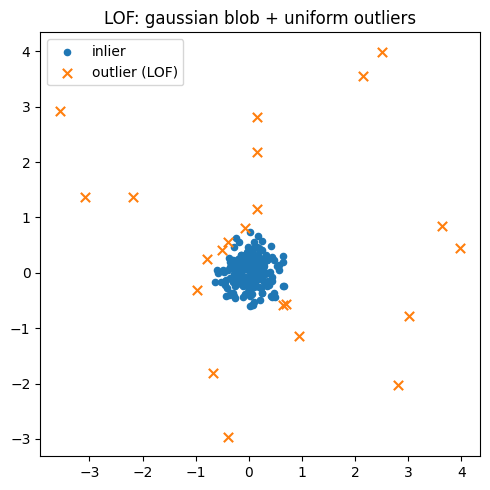

In [19]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

rng = np.random.RandomState(42)

# 正常点（高斯团）+ 少量离群点（均匀散布）
X_in = 0.3 * rng.randn(200, 2)
X_out = rng.uniform(low=-4, high=4, size=(15, 2))
X = np.vstack([X_in, X_out])

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
labels = lof.fit_predict(X)

inlier_mask = labels == 1
outlier_mask = labels == -1

print("总样本数         :", len(X))
print("LOF 判为离群点   :", int(outlier_mask.sum()))
print("其中确实来自 X_out:", int(outlier_mask[len(X_in):].sum()), "/", len(X_out))
print()
print("negative_outlier_factor_ 越小越异常，前 5 个:",
      np.round(lof.negative_outlier_factor_[:5], 3))

plt.figure(figsize=(5, 5))
plt.scatter(X[inlier_mask, 0], X[inlier_mask, 1], s=20, label="inlier")
plt.scatter(X[outlier_mask, 0], X[outlier_mask, 1], s=45, marker="x", label="outlier (LOF)")
plt.title("LOF: gaussian blob + uniform outliers")
plt.legend()
plt.tight_layout()
plt.show()

## 13. 小结

- **数学层**：距离只在需要时才算真实值（平方欧氏 + 延迟开方、`radius *= radius`）；metric 会按 `p` 坍缩特化；`p<1` 因为半度量被禁树；零距离样本在 `distance` 权重下被"一票定音"；半径结果稳定排序。
- **数据结构层**：Top-k 用 `argpartition` 而非排序（但必须补一次小排序）；`auto` 的阈值是硬编码经验；稀疏距离矩阵可当图，ragged 用 `np.take(mode="clip")` 压平；半径版返回 object 数组。
- **架构层**：`fit` 只建索引、索引可跨模型复用；抽象基类 + Mixin 组合；`kneighbors` 分四条路径，`n_jobs` 语义随后端而变；`query==train` 的自身排除与重复点边界；离群点用"全零概率"判定。